# Polytropic ideal reactors - Hydrolysis of Ethylene Oxide (EO) to Ethylene Glycol (EG)

### Chemical Reaction Engineering 3 - Assignment 3

Group 4 
- Julian Stierstorfer (1160552)
- Kartik Nair ()
- Sanskar Nashier ()





## Table of Contents

1. Introduction

2. Theoretical Background

   2.1 Mass and energy balances

   2.2 DSTR model

   2.3 PFTR model

   2.4 Main differences between DSTR and PFTR balances

3. Python Implementation

   3.1 Basic parameters of the tubular reactor

   3.2 Implementation of mass and energy balances as well as kinetics

   3.3 Temperature and concentration profiles for initial case

   3.4 Conversion

4. Variation of Process Parameters

   4.1 Evaluation criteria

   4.2 Influence of flow velocity

   4.3 Influence of inlet temperature

   4.4 Influence of inlet EO concentration

   4.5 Influence of wall temperature

   4.6 Comparison of process parameter effects

5. Variation of Reactor Dimensions and Design Parameters

   5.1 Evaluation criteria

   5.2 Influence of reactor length

   5.3 Influence of reactor diameter

   5.4 Influence of heat-transfer coefficient

   5.5 Comparison of reactor parameter effects

   5.6 Selection of final parameter set

Literature

AI Use and Reflection

   Tools Used

   Areas of Use

   Prompting Strategy

   Critical Examination of AI Outputs

## 1. Introduction

The hydrolysis of ethylene oxide ($\mathrm{EO}$) to ethylene glycol ($\mathrm{EG}$) is an industrially relevant liquid-phase reaction carried out in a water-based solvent system. Ethylene oxide is an important chemical intermediate and is mainly used for the production of ethylene glycol and other oxygen-containing products. Ethylene glycol is widely applied as a raw material for polyester production and as a component in antifreeze and coolant formulations.

\begin{equation}
\mathrm{EO} + \mathrm{H_2O} \rightarrow \mathrm{EG}
\qquad
\Delta_\mathrm{R}H = -96\,000~\mathrm{J\,mol^{-1}}
\tag{1}
\end{equation}

The negative reaction enthalpy in eq. (1) shows that the hydrolysis is strongly exothermic. This is important from a reaction engineering perspective, because the released heat can increase the reactor temperature. Since the reaction rate is temperature-dependent, an increase in temperature accelerates the reaction and may further increase heat generation. Therefore, the thermal stability of the reaction system and the possible formation of temperature maxima have to be investigated.

The modelling approach used in this assignment is based on the derivation of a discontinuous stirred tank reactor model first. In the DSTR, ideal mixing is assumed, so concentrations and temperature depend only on time. In a second step, this model is adapted to a plug-flow tubular reactor by applying a time-space transformation. The temporal coordinate of the DSTR is transferred to the axial coordinate of the PFTR by using the local residence time $\tau(z)$. For the full reactor length $L_\mathrm{R}$, the residence time is given by $\tau$.

\begin{equation}
\tau(z) = \frac{z}{u}
\qquad \text{and} \qquad
\tau = \frac{L_\mathrm{R}}{u}
\tag{2}
\end{equation}

Thus, the time-dependent reactor behaviour is transformed into spatial concentration and temperature profiles along the reactor length.

Mathematically, the main challenge is the coupling of mass and energy balances. The mass balances describe the consumption of $\mathrm{EO}$ and the formation of $\mathrm{EG}$, while the energy balance accounts for heat generation by the exothermic reaction and heat exchange with the reactor wall. Since the reaction rate depends on temperature and the temperature depends on the heat released by the reaction, both balances have to be solved simultaneously.

To evaluate the sensitivity of the reaction system, selected operating and design parameters are varied. These include the inlet temperature, wall temperature, inlet concentration, flow velocity, reactor length, reactor diameter and heat-transfer coefficient. The resulting effects on conversion, outlet temperature and maximum reactor temperature are analysed. Finally, the numerical results are compared with literature-based expectations and limiting cases, such as isothermal and adiabatic reactor behaviour, to assess the plausibility of the implemented model.
```


## 2. Theoretical Background - discontinuous stirred tank reactor (DSTR) and plug-flow tubular reactor (PFTR)


### 2.1 Mass and energy balances

The reactor model is based on coupled component and energy balances. The component balances describe the change of the concentrations due to chemical reaction, while the energy balance describes the temperature change caused by reaction heat and heat transfer through the reactor wall. For the hydrolysis of ethylene oxide, the reaction is treated as a single irreversible reaction:

\begin{equation}
\mathrm{EO} + \mathrm{H_2O} \rightarrow \mathrm{EG}
\tag{3}
\end{equation}

In the water-based solvent system, water is present in large excess. Therefore, the reaction rate can be formulated as <br> pseudo-first order with respect to $\mathrm{EO}$:

\begin{equation}
r = k(T)c_\mathrm{EO}
\tag{4}
\end{equation}

The temperature dependence of the reaction rate constant is described by an Arrhenius expression:

\begin{equation}
k(T) = k_0 \exp\left(-\frac{E_\mathrm{A}}{RT}\right)
\tag{5}
\end{equation}

### 2.2 DSTR model

In the discontinuous stirred tank reactor, ideal mixing is assumed. Thus, the concentrations and temperature are spatially uniform inside the reactor and only change with time. Since there is no inlet or outlet stream during the reaction, the component balance only contains the reaction term.

For a general reaction network, the component balance is:

\begin{equation}
\frac{dc_i}{dt}
=
\sum_{j=1}^{M} \nu_{i,j} r_j
\tag{6}
\end{equation}

For the single hydrolysis reaction, this gives:

\begin{equation}
\frac{dc_\mathrm{EO}}{dt}
=
-r
\tag{7}
\end{equation}

\begin{equation}
\frac{dc_\mathrm{EG}}{dt}
=
r
\tag{8}
\end{equation}

The energy balance contains heat generation by the exothermic reaction and heat exchange with the reactor wall:

\begin{equation}
\rho c_p
\frac{dT}{dt}
=
-\Delta_\mathrm{R}H \, r
-
\frac{h_\mathrm{W} A_\mathrm{W}}{V_\mathrm{R}}
\left(T - T_\mathrm{K}\right)
\tag{9}
\end{equation}

The first term on the right-hand side describes the heat released by reaction. Since $\Delta_\mathrm{R}H < 0$, the term $-\Delta_\mathrm{R}H r$ is positive and increases the reactor temperature. The second term describes heat removal if $T > T_\mathrm{K}$.

The DSTR model is solved as an initial value problem with:

\begin{equation}
c_\mathrm{EO}(t=0)=c_{\mathrm{EO},0},
\qquad
c_\mathrm{EG}(t=0)=0,
\qquad
T(t=0)=T_0
\tag{10}
\end{equation}

### 2.3 PFTR model

[MAYBE ADD PICTURE OF PFTR FOR BALANCE EQUATIONS]

In the plug-flow tubular reactor, ideal radial mixing and no axial backmixing are assumed. Therefore, the variables are not functions of time, but of the axial coordinate $z$ for the steady-state case. The transformation from the DSTR model to the PFTR model is based on the local residence time:

\begin{equation}
\tau(z)=\frac{z}{u}
\tag{11}
\end{equation}

For a constant flow velocity $u$, the time derivative of the DSTR model can therefore be transferred to an axial derivative according to:

\begin{equation}
\frac{d}{dt}
\rightarrow
u\frac{d}{dz}
\tag{12}
\end{equation}

The general steady-state component balance of the PFTR is:

\begin{equation}
u\frac{dc_i}{dz}
=
\sum_{j=1}^{M} \nu_{i,j} r_j
\tag{13}
\end{equation}

For the hydrolysis reaction, the component balances become:

\begin{equation}
u\frac{dc_\mathrm{EO}}{dz}
=
-r
\tag{14}
\end{equation}

\begin{equation}
u\frac{dc_\mathrm{EG}}{dz}
=
r
\tag{15}
\end{equation}

The corresponding energy balance is:

\begin{equation}
u \rho c_p
\frac{dT}{dz}
=
-\Delta_\mathrm{R}H \, r
-
\frac{4h_\mathrm{W}}{d_\mathrm{R}}
\left(T - T_\mathrm{K}\right)
\tag{16}
\end{equation}

The heat-transfer term differs from the DSTR formulation since the tubular reactor geometry is expressed <br> by the surface-to-volume ratio of a tube $\left(\frac{A_\mathrm{W}}{V_\mathrm{R}}=\frac{4}{d_\mathrm{R}}\right)$.

The PFTR model is solved as an initial value problem along the reactor length with inlet boundary conditions:

\begin{equation}
c_\mathrm{EO}(z=0)=c_{\mathrm{EO},e},
\qquad
c_\mathrm{EG}(z=0)=0,
\qquad
T(z=0)=T_e
\tag{17}
\end{equation}

### 2.4 Main differences between DSTR and PFTR balances

The DSTR describes the temporal development of one ideally mixed reactor volume. Therefore, the independent variable is time $t$, and the model predicts how concentrations and temperature change during the batch reaction.

The PFTR describes the spatial development along the reactor length. Therefore, the independent variable is the axial coordinate $z$, or equivalently the local residence time $\tau(z)$. The model predicts concentration and temperature profiles from the reactor inlet to the outlet.

Both models contain the same reaction term and the same thermal coupling between reaction rate and temperature. The main difference is the transport description: in the DSTR, the whole reactor volume has one concentration and temperature at each time. In the PFTR, each axial position represents a different reaction progress, while axial backmixing is neglected.
```


## 3. Python Implementation

The derived balance equations are implemented into `Python 3.12` using `scipy`and `numpy` for numerical calculation and `matplotlib` for visualization.

### 3.1 Basic parameters of the tubular reactor

For an initial study a set of base-case parameters can be used:

| Quantity | Symbol | Default |
| --- | --- | --- |
| Fluid velocity | $u$ | $1.0\,\mathrm{m\,s^{-1}}$ |
| Reactor length | $L$ | $300\,\mathrm{m}$ |
| Tube diameter | $d_\mathrm{R}$ | $0.03\,\mathrm{m}$ |
| EO inlet concentration | $c_{\mathrm{EO},in}$ | $2.27 \cdot 10^3\,\mathrm{mol\,m^{-3}}$ |
| Inlet temperature | $T_{in}$ | $423\,\mathrm{K}$ |
| Wall temperature | $T_\mathrm{wall}$ | $423\,\mathrm{K}$ |
| Density | $\rho$ | $1000\,\mathrm{kg\,m^{-3}}$ |
| Heat capacity | $c_p$ | $4.19 \cdot 10^3\,\mathrm{J\,kg^{-1}\,K^{-1}}$ |
| Reaction enthalpy | $\Delta_\mathrm{R}H$ | $-92.2 \cdot 10^3\,\mathrm{J\,mol^{-1}}$ |
| Wall heat-transfer coefficient | $h_\mathrm{wall}$ | $0.5 \cdot 10^3\,\mathrm{J\,s^{-1}\,m^{-2}\,K^{-1}}$ |
| Ideal gas constant | $R$ | $8.314\,\mathrm{J\,mol^{-1}\,K^{-1}}$ |
| Pre-exponential factor | $k_0$ | $5.01\,\mathrm{s^{-1}}$ |
| Activation energy | $E_A$ | $72\,500\,\mathrm{J\,mol^{-1}}$ |

These parameters can be implemented into the Python code:

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Given base parameters

u = 1.0                         # fluid velocity, m s^-1
L = 300.0                       # reactor length, m
d_R = 0.03                      # tube diameter, m

c_EO_in = 2.27e3                # EO inlet concentration, mol m^-3
c_EG_in = 0.0                   # EG inlet concentration, mol m^-3
T_in = 423.0                    # inlet temperature, K
T_wall = 423.0                  # wall temperature, K

rho = 1000.0                    # density, kg m^-3
cp = 4.19e3                     # heat capacity, J kg^-1 K^-1

delta_H_R = -92.2e3             # reaction enthalpy, J mol^-1
h_wall = 0.5e3                  # wall heat-transfer coefficient, J s^-1 m^-2 K^-1


# Kinetic and thermodynamic data

R = 8.314                       # ideal gas constant, J mol^-1 K^-1

k_0 = 5.01e6                      # pre-exponential factor, s^-1
E_A = 72_500.0                  # activation energy, J mol^-1

# importing the ICIW style sheet for plotting

import ICIW_Plots
import ICIW_Plots.colors as ICIWcolors

iciw_package_dir = os.path.dirname(ICIW_Plots.__file__)

# Read all .mplstyle files from the ICIW_Plots package directory
iciw_styles = plt.style.core.read_style_directory(iciw_package_dir)

# Register them in Matplotlib's style library for this Python session
plt.style.core.library.update(iciw_styles)

# Refresh the list of available style names
plt.style.core.available[:] = sorted(plt.style.core.library.keys())

print([style for style in plt.style.available if "ICIW" in style])

plt.style.use("ICIWstyle")

# add viridis as well as custom paulaner spezi colormap

import matplotlib as mpl
from matplotlib.colors import ListedColormap

# Viridis colormap for continuous parameter variations
viridis = plt.colormaps["viridis"]

# Paulaner-Spezi-inspired discrete color palette
spezi_colors = [
    "#F28C00",  # orange
    "#FFD200",  # yellow
    "#C8102E",  # red
    "#6F2C00",  # brown
    "#3A1F04",  # dark brown
    "#A65A00",  # caramel
    "#7A1E00",  # dark red-brown
    "#FFF3B0"   # light yellow
]

spezi_cmap = ListedColormap(spezi_colors, name="paulaner_spezi")

# Optional: register the custom colormap globally
try:
    mpl.colormaps.register(spezi_cmap)
except ValueError:
    pass  # colormap is already registered

['ICIWlatex', 'ICIWnobg', 'ICIWstyle']


### 3.2 Implementation of mass and energy balances as well as kinetics
The before discussed mass and energy balances for the PFTR can be implemented as well. Therefore, a `kinetics`- as well as a `pftr`-function is created.

In [22]:
def kinetics(c_EO, T):
    """
    Calculate the pseudo-first-order reaction rate.

    Parameters
    ----------
    c_EO : float
        EO concentration, mol m^-3
    T : float
        Temperature, K

    Returns
    -------
    r : float
        Reaction rate, mol m^-3 s^-1
    """
    k = k_0 * np.exp(-E_A / (R * T))      # reaction rate constant, s^-1

    r = k * c_EO                          # reaction rate, mol m^-3 s^-1

    return r

def pftr(z, y):
    """
    Define the PFTR balance equations.

    Parameters
    ----------
    z : float
        Axial reactor coordinate, m
    y : array-like
        State vector containing c_EO, c_EG and T.

    Returns
    -------
    dydz : list
        Axial derivatives dc_EO/dz, dc_EG/dz and dT/dz.
    """
    c_EO, c_EG, T = y

    r = kinetics(c_EO, T)

    dc_EO_dz = -r / u

    dc_EG_dz = r / u

    dT_dz = (
        -delta_H_R * r
        - (4 * h_wall / d_R) * (T - T_wall)
    ) / (u * rho * cp)

    return [dc_EO_dz, dc_EG_dz, dT_dz]

### 3.3 Temperature and concentration profiles for initial case

The PFTR model is solved as an initial value problem along the axial reactor coordinate $z$. 
The inlet state is used as the initial condition at $z=0$. Since water is present in large excess, the numerical state vector contains the ethylene oxide concentration, the ethylene glycol concentration and the reactor temperature:

\begin{equation}
\begin{bmatrix}
c_{\mathrm{EO},0} \\
c_{\mathrm{EG},0} \\
T_0
\end{bmatrix}
=
\begin{bmatrix}
2270 \\
0 \\
423
\end{bmatrix}
\begin{bmatrix}
\mathrm{mol\,m^{-3}} \\
\mathrm{mol\,m^{-3}} \\
\mathrm{K}
\end{bmatrix}
\tag{18}
\end{equation}

The model is integrated over the full reactor length from the inlet to the outlet:

\begin{equation}
z_{\mathrm{span}} =
\begin{bmatrix}
0 & L
\end{bmatrix}
=
\begin{bmatrix}
0 & 300
\end{bmatrix}
\,\mathrm{m}
\tag{19}
\end{equation}

Thus, the numerical solution provides the concentration and temperature profiles $c_{\mathrm{EO}}(z)$, $c_{\mathrm{EG}}(z)$ and $T(z)$ along the reactor length.

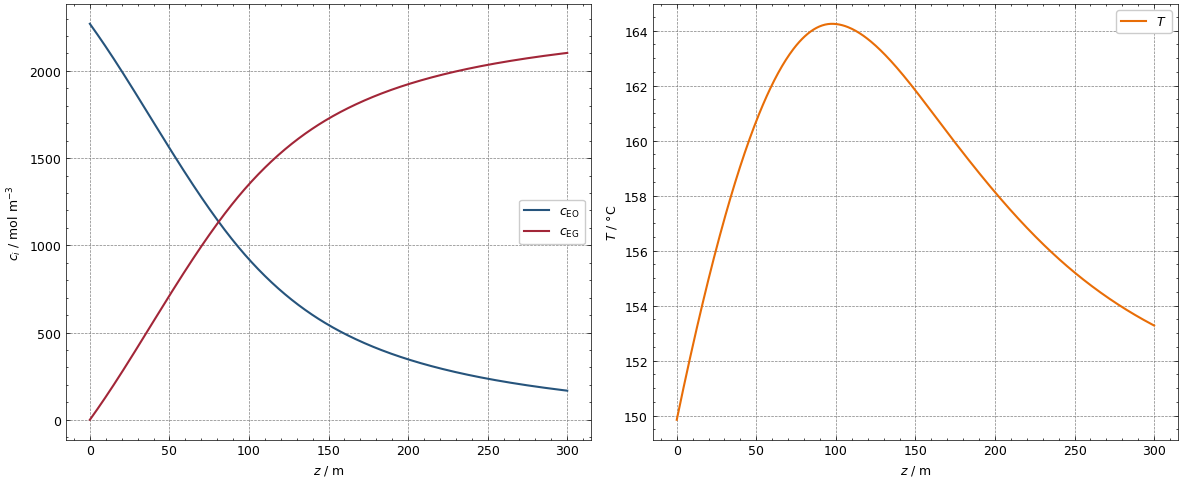

In [23]:
# Initial conditions

y0 = np.array([
    c_EO_in,                    # initial EO concentration, mol m^-3
    c_EG_in,                    # initial EG concentration, mol m^-3
    T_in                        # initial temperature, K
])

# Integration domain along reactor length

z_span = (0.0, L)               # integration interval, m
z_eval = np.linspace(0.0, L, 500)  # axial positions for solution output, m

# Solve initial value problem

solution = solve_ivp(
    fun=pftr,
    t_span=z_span,
    y0=y0,
    t_eval=z_eval,
    method="RK45"
)

# Extract solution data

z = solution.t                  # axial reactor coordinate, m

c_EO = solution.y[0]            # EO concentration, mol m^-3
c_EG = solution.y[1]            # EG concentration, mol m^-3
T = solution.y[2]               # temperature, K


# Plot concentration and temperature profiles
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Concentration profiles
axes[0].plot(z, c_EO, label=r"$c_{\mathrm{EO}}$", color=ICIWcolors.CERULEAN)
axes[0].plot(z, c_EG, label=r"$c_{\mathrm{EG}}$", color=ICIWcolors.CRIMSON)

axes[0].set_xlabel(r"$z$ / m")
axes[0].set_ylabel(r"$c_i$ / mol m$^{-3}$")
axes[0].legend()

# Temperature profile
axes[1].plot(z, T - 273.15, label=r"$T$", color=ICIWcolors.FLAME)

axes[1].set_xlabel(r"$z$ / m")
axes[1].set_ylabel(r"$T$ / °C")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Conversion 

The reactor performance is evaluated from the concentration profiles of $\mathrm{EO}$ and $\mathrm{EG}$. 
The conversion describes the fraction of initially supplied $\mathrm{EO}$ that has reacted:

\begin{equation}
X_{\mathrm{EO}} =
\frac{c_{\mathrm{EO},0} - c_{\mathrm{EO}}}{c_{\mathrm{EO},0}}
\tag{20}
\end{equation}

Since the reaction system only consists of the reaction $A \rightarrow B$, this is equal to the yield $Y$. The conversion can be calculated at the outlet which is an important reactor performance indicator. Additionally, the conversion can also be calculated for incremental steps of the reactor length. Therefore, a conversion-profile can be visualized.

In [24]:
def calculate_conversion(c_EO, c_EO_0=c_EO_in):
    """
    Calculate EO conversion along the PFTR.

    Parameters
    ----------
    c_EO : float or array-like
        EO concentration, mol m^-3
    c_EO_0 : float
        Initial EO concentration, mol m^-3

    Returns
    -------
    X_EO : float or array-like
        EO conversion, -
    """
    c_EO = np.asarray(c_EO)

    X_EO = (c_EO_0 - c_EO) / c_EO_0         # EO conversion, -

    return X_EO

Outlet EO conversion = 0.9265


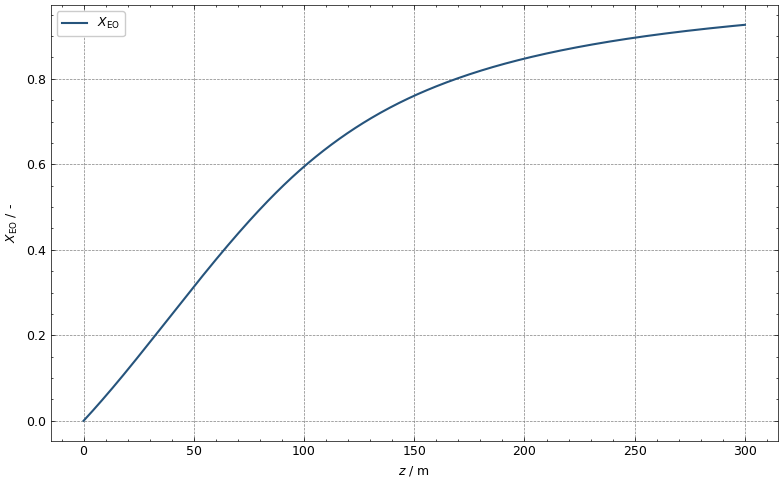

In [25]:
X_EO = calculate_conversion(c_EO)

X_EO_out = calculate_conversion(c_EO[-1])

print(f"Outlet EO conversion = {X_EO_out:.4f}")

# Plot conversion profile

plt.figure(figsize=(8, 5))

plt.plot(z, X_EO, label=r"$X_{\mathrm{EO}}$", color=ICIWcolors.CERULEAN)

plt.xlabel(r"$z$ / m")
plt.ylabel(r"$X_{\mathrm{EO}}$ / -")
plt.legend()

plt.tight_layout()
plt.show()


## 4. Variation of Process Parameters

### 4.2 Influence of Flow Velocity



### 4.3 Influence of Inlet Temperature



### 4.4 Influence of Inlet EO Concentration



### 4.5 Influence of Wall Temperature



### 4.6 Comparison of Process Parameter Effects


## 5. Variation of Reactor Dimensions and Design Parameters



### 5.1 Evaluation Criteria



### 5.2 Influence of Reactor Length



### 5.3 Influence of Reactor Diameter



### 5.4 Influence of Heat-Transfer Coefficient



### 5.5 Comparison of Reactor Parameter Effects



### 5.6 Selection of Final Parameter Set

## Literature

| No. | Source |
|---:|---|
| [1] | Güttel, R.; Turek, T. *Chemische Reaktionstechnik*. Springer Spektrum, 2021. |

## AI Use and Reflection

This section documents the use of AI tools during the preparation of this assignment. The documentation follows the required structure for transparent AI use, including the tools used, the areas of use, the prompting strategy, verification steps, and a statement of own contribution.

### Tools Used

The following AI tools were used during the preparation of this assignment:

| Tool | Model / Version | Date of Use | Purpose |
|---|---|---:|---|
| [Tool name] | [Model/version] | [Month Year] | [e.g. code debugging, concept clarification, language editing] |
| [Tool name] | [Model/version] | [Month Year] | [purpose] |

### Areas of Use

AI tools were used for the following subtasks:

| Area | Use of AI | Own follow-up / verification |
|---|---|---|
| Concept clarification | [Describe what was clarified, e.g. PFTR/DSTR balance interpretation] | [How understanding was checked against lecture notes/textbook] |
| Code generation/debugging | [Describe which part of the code was supported] | [State how the code was independently tested] |
| Verification strategy | [Describe suggested checks, limiting cases, unit checks] | [State which checks were actually applied] |
| Language editing | [Grammar/readability only] | [Scientific content and conclusions reviewed by authors] |
| Interpretation of results | [Only if applicable; describe carefully] | [State that final interpretation and conclusions were made independently] |

### Prompting Strategy

For substantive AI use, the prompting strategy was based on providing the assignment context, the implemented balance equations, relevant assumptions, and the current Python implementation. The AI tool was then asked for targeted support, such as identifying possible implementation errors, suggesting verification checks, or improving code readability.

Typical prompting workflow:

1. The relevant modelling context was provided, including the reactor type, reaction system, assumptions, and implemented equations.
2. The AI tool was asked for a specific task, for example checking sign conventions, suggesting limiting cases, or commenting on code structure.
3. The output was not used directly, but compared with the assignment documentation, lecture material, textbook equations, and numerical plausibility checks.
4. Only verified suggestions were incorporated into the final implementation or report.

For purely linguistic use, AI was only used after the scientific content had already been formulated.

### Critical Examination of AI Outputs

[To be completed.]